## Decision Trees

In this notebook you will experiment with different tree based algorithms on some different datasets. You will need to:


Create 3 models:

1. DecisionTreeClassifier()
2. RandomForestClassifier()
3. XGBClassifier()

These will be inserted into the dictionaries below for comparison.

You will also get a feeling for the different hyperparameters for each of these methods. Along with this, I want you to get used to reading the documentation of the different APIs. I will provide you with links.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.training



In [1]:
%pwd

'/home/djanuskiewicz/AI4Fusion_2026/Project/Decision_Trees_Classification'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification,make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv('../data/cmod_clean_200ms.csv')

In [4]:
df.tail()

,Unnamed: 0,shot,time,a_minor,beta_n,beta_p,bt,chisq,dbetap_dt,dip_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
526246,940515,1140211006,1.40,0.224153,0.339973,0.154231,5.386440,16.781702,-0.331477,1.168480e+06,...,1.201284,1.376992,1.444858,0.453785,42894.128906,0.001341,0.009012,0.004698,0.010353,0
526247,940516,1140211006,1.42,0.223878,0.299285,0.135459,5.383023,16.955473,-0.412427,1.166281e+06,...,1.849325,1.403160,1.442194,2.715747,37786.804688,0.001066,0.009013,0.027374,0.010080,0
526248,940517,1140211006,1.44,0.223053,0.303324,0.137733,5.381559,17.233974,0.174302,3.947276e+05,...,1.362813,1.478647,1.366938,-1.838071,38398.691406,-0.000196,0.009014,-0.016207,0.008818,0
526249,940518,1140211006,1.46,0.222101,0.311538,0.142431,5.382535,17.893890,-0.054488,1.172580e+06,...,1.213075,1.496440,1.393111,-3.417095,39519.207031,0.000273,0.009016,-0.031741,0.009288,0
526250,940519,1140211006,1.48,0.221867,0.296491,0.135554,5.384487,17.898066,-0.081536,2.661531e+03,...,1.475937,1.348752,1.368059,3.174205,37524.597656,0.000014,0.009017,0.028663,0.009030,0


array([[<Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>],
       [<Axes: title={'center': 'ip'}>,
        <Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>],
       [<Axes: title={'center': 'lower_gap'}>,
        <Axes: title={'center': 'n_e'}>,
        <Axes: title={'center': 'p_icrf'}>,
        <Axes: title={'center': 'p_input'}>,
    

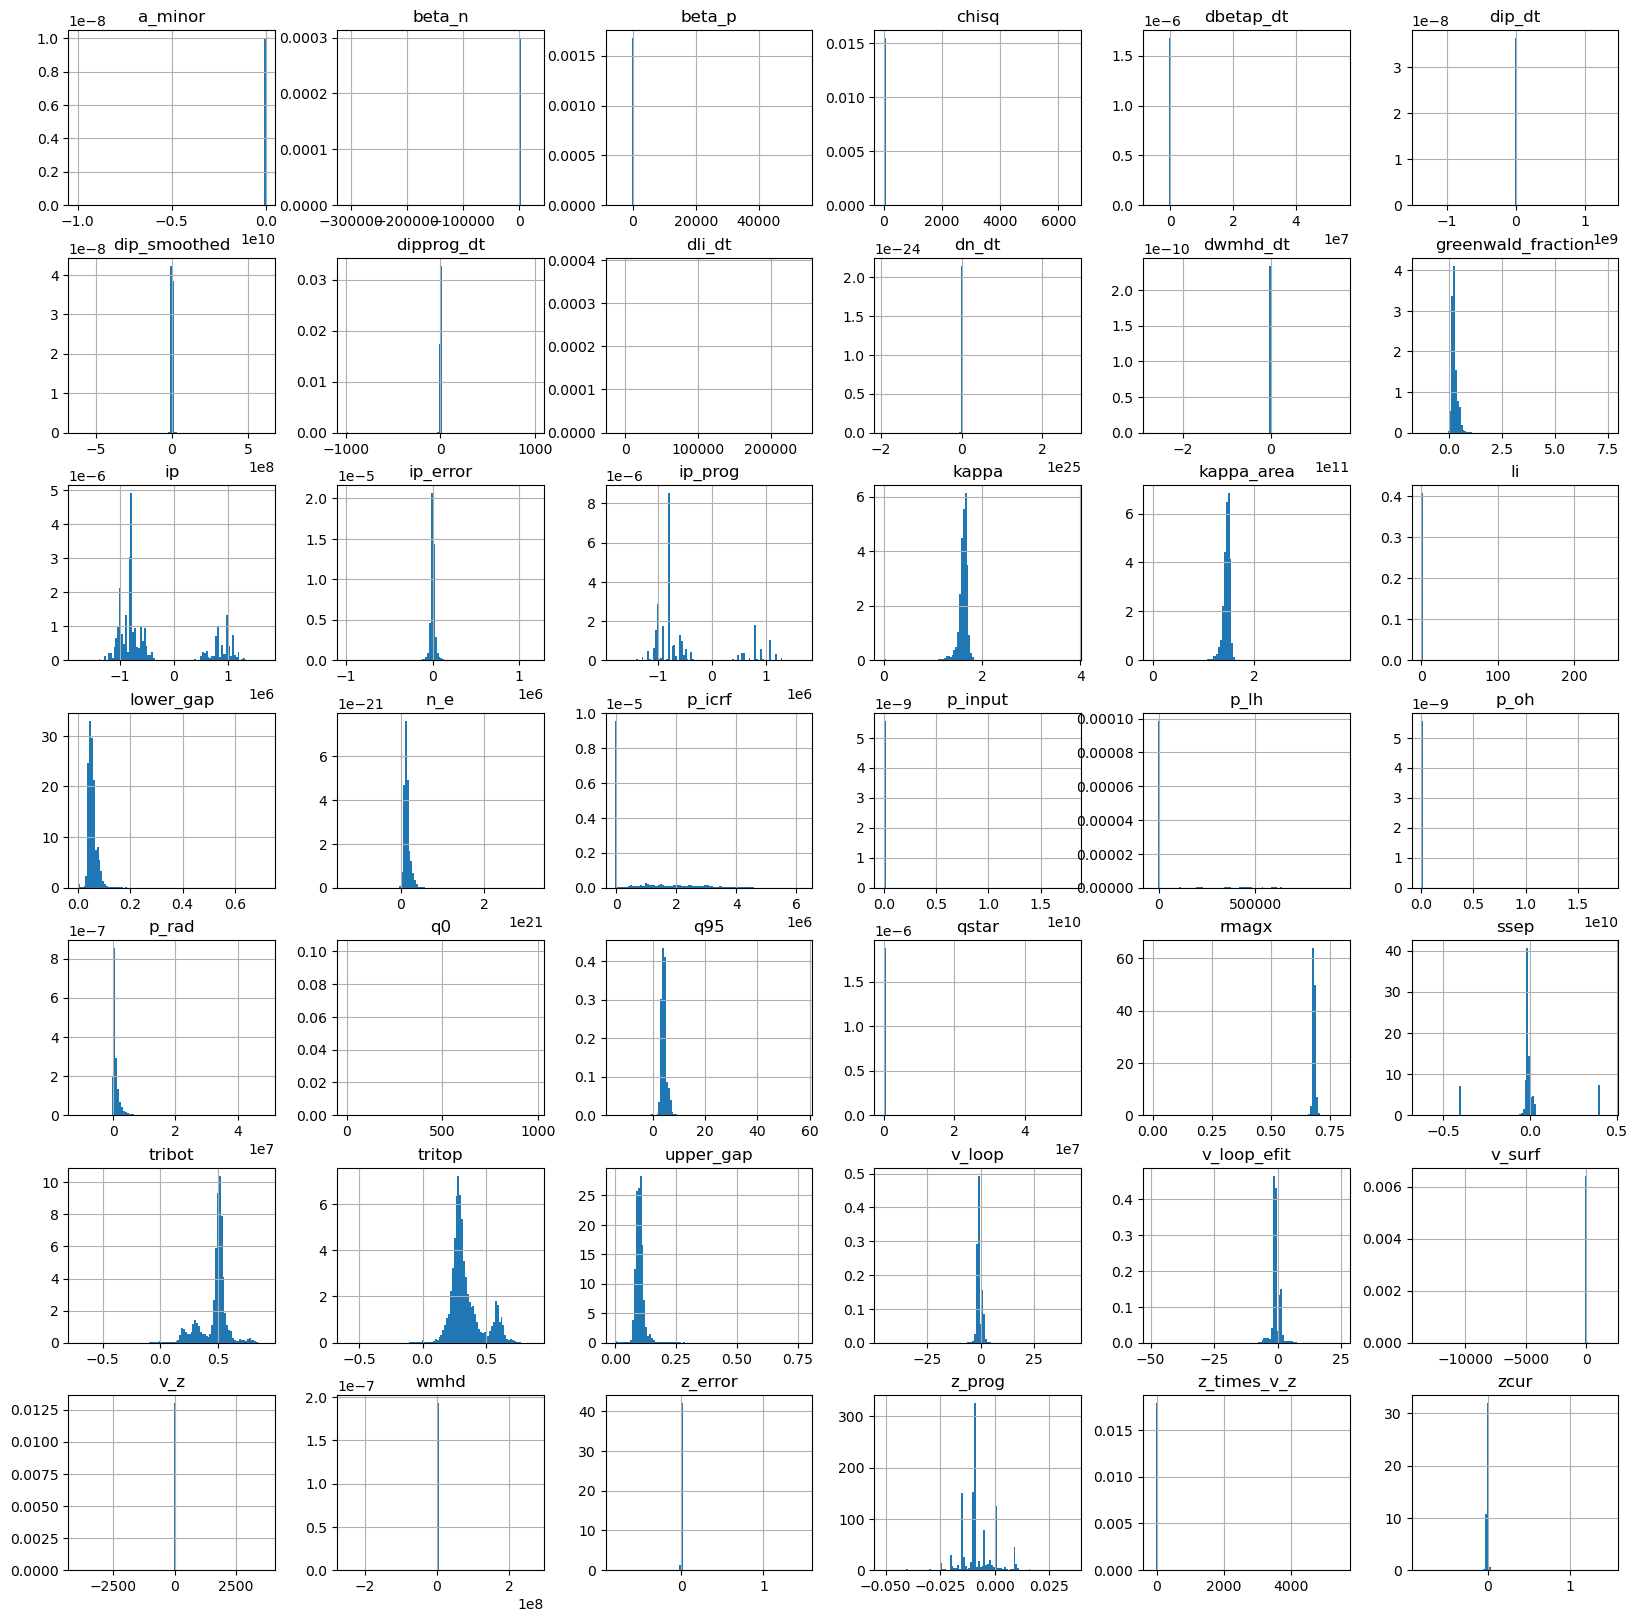

In [5]:
# Flag columns with NaNs and infinities

X = df.drop(['Unnamed: 0', 'shot', 'time', 'disruptive', 'time_until_disrupt'], axis=1)

# drop nans and infinities
shot_filter = X.isna() | X.isin([np.inf, -np.inf])
columns_with_nan_or_inf = X.columns[shot_filter.any()].tolist()

X = X.drop(columns_with_nan_or_inf, axis=1)
#X.head()
X.hist(figsize=(20,20),bins=100,density=True)

In [6]:
y = df['disruptive']

# split into train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True, stratify=y
)

In [7]:
disrupt_fraction = y.mean()
print(disrupt_fraction) # Use to adjust weighting less infrequent disruptive class
scale_pos_weight = (1-disrupt_fraction)/disrupt_fraction

0.08414425815817927


In [8]:
# Train a random forest using XGBoost to predict whether a shot is disruptive or not
models = [
    XGBClassifier(eval_metric="logloss", random_state=42),
    XGBClassifier(eval_metric="logloss", random_state=42, subsample=0.8, scale_pos_weight=scale_pos_weight),
    XGBClassifier(eval_metric="logloss", random_state=42, max_depth=8),
    XGBClassifier(eval_metric="logloss", random_state=42, max_depth=8, subsample=0.8, scale_pos_weight=scale_pos_weight),
]
names = ["Standard arguments", "Increased disruption weight", "Deeper tree", "Deep tree & more weight"]
results = {}

for model, name in zip(models, names):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    preds = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results[name] = (model, train_acc, test_acc, train_time, preds)
    
    print(name)
    print(f"  → Train Accuracy: {train_acc:.3f}")
    print(f"  → Test  Accuracy: {test_acc:.3f}")
    print(f"  → Train Time    : {train_time*1000:.2f} ms\n")



Standard arguments
  → Train Accuracy: 0.984
  → Test  Accuracy: 0.978
  → Train Time    : 1397.58 ms

Increased disruption weight
  → Train Accuracy: 0.971
  → Test  Accuracy: 0.962
  → Train Time    : 1565.92 ms

Deeper tree
  → Train Accuracy: 0.991
  → Test  Accuracy: 0.979
  → Train Time    : 2021.67 ms

Deep tree & more weight
  → Train Accuracy: 0.989
  → Test  Accuracy: 0.974
  → Train Time    : 2189.43 ms



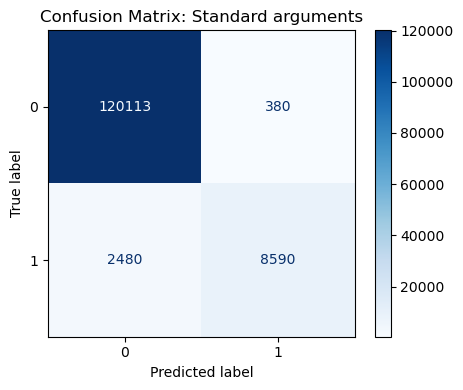

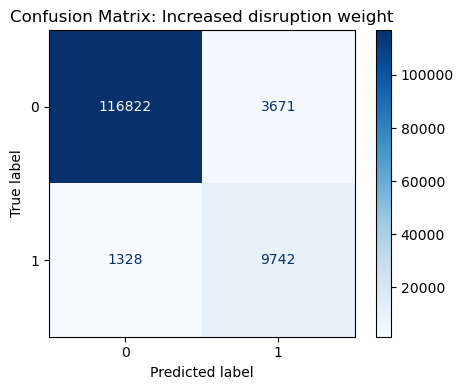

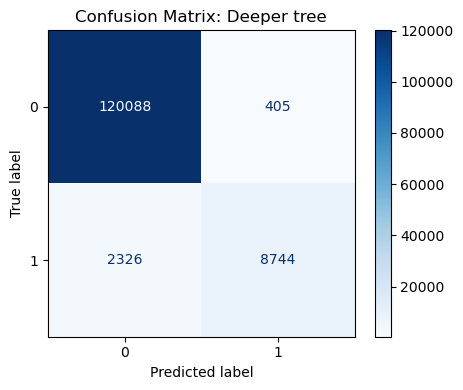

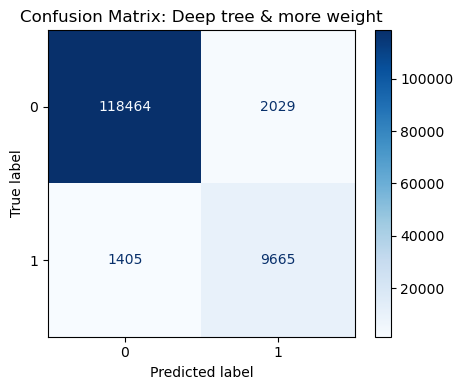

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

# Custom shortened identifiers matching the order of your names list
file_suffixes = ["std", "weighted", "deep", "deep_weighted"]

for name, suffix in zip(names, file_suffixes):
    # Extract predictions (the 5th entry, index 4, in the tuple)
    model_preds = results[name][4]
    
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, model_preds)
    
    # Set up the plot for this specific model
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
    
    # Dynamic title based on the model's configuration name
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()

    plt.savefig(f"xgboost_conf_mat_{suffix}.png", format="png", bbox_inches="tight")
    plt.show()

In [10]:
y_true = y_test
predictions = preds
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

              precision    recall  f1-score   support

           0       0.99      0.98      0.99    120493
           1       0.83      0.87      0.85     11070

    accuracy                           0.97    131563
   macro avg       0.91      0.93      0.92    131563
weighted avg       0.97      0.97      0.97    131563

Precision: 0.8264922182315717
Recall: 0.8730803974706414
F1 Score: 0.8491477771920576


In [11]:
inf_counts = df.isin([np.inf, -np.inf]).sum()
print(inf_counts[inf_counts > 0])

radiated_fraction    1
dtype: int64


In [12]:
importances = models[3].feature_importances_
names = X.columns

In [13]:
feature_names = list(X.columns)

In [14]:
mapping = np.argsort(-importances)

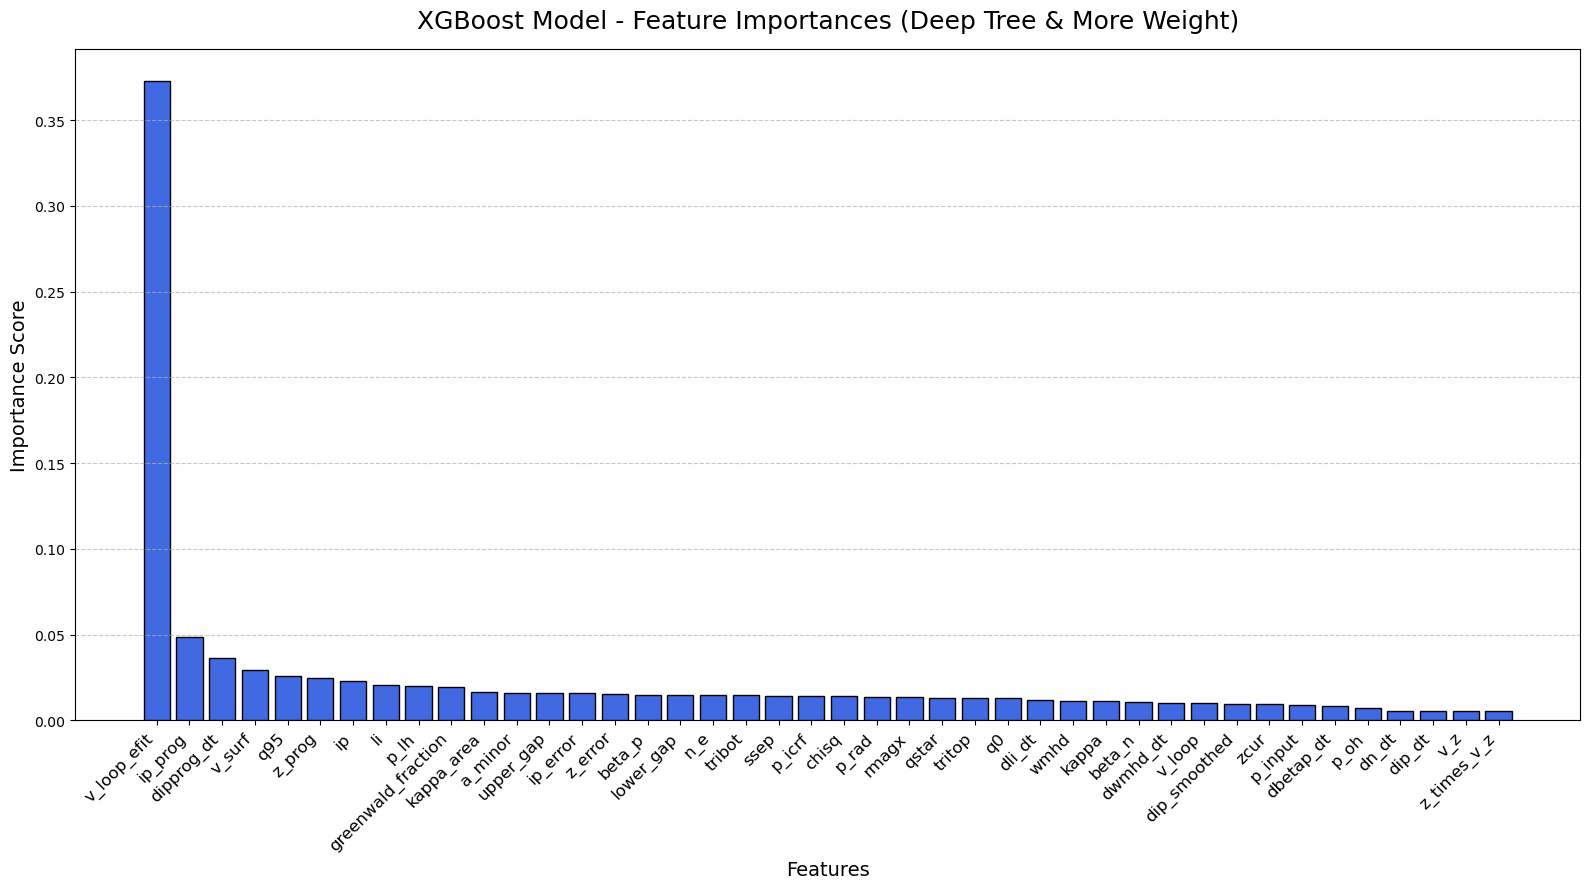

In [15]:
plt.figure(figsize=(16, 9))
features_in_order_of_importance = np.array(feature_names)[mapping]

# Plot the bars using your sorted mapping for a much cleaner look
plt.bar(features_in_order_of_importance, importances[mapping], color="royalblue", edgecolor="black")

# Add descriptive titles and labels
plt.title("XGBoost Model - Feature Importances (Deep Tree & More Weight)", fontsize=18, pad=15)
plt.ylabel("Importance Score", fontsize=14)
plt.xlabel("Features", fontsize=14)

# Align the ticks properly
plt.xticks(rotation=45, ha='right', fontsize=12)

# Grid lines for easier readability (optional but helpful)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("xgboost_feature_importances.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [16]:
!python -m pip install catboost

In [17]:
# CATBOOST
from catboost import CatBoostClassifier, Pool

dataset = Pool(X_train, label=y_train)
# Add weight
catboost_model = CatBoostClassifier(
    scale_pos_weight=scale_pos_weight,
    verbose=100,  # Keeps the output clean
    random_state=42
)

#train the model
catboost_model.fit(dataset)

Learning rate set to 0.132292
0:	learn: 0.5666849	total: 68.5ms	remaining: 1m 8s
100:	learn: 0.2255580	total: 2.1s	remaining: 18.7s
200:	learn: 0.1870229	total: 4.22s	remaining: 16.8s
300:	learn: 0.1640883	total: 6.36s	remaining: 14.8s
400:	learn: 0.1470789	total: 8.58s	remaining: 12.8s
500:	learn: 0.1335788	total: 11s	remaining: 10.9s
600:	learn: 0.1226675	total: 13.1s	remaining: 8.7s
700:	learn: 0.1130162	total: 15.2s	remaining: 6.5s
800:	learn: 0.1049581	total: 17.3s	remaining: 4.3s
900:	learn: 0.0979969	total: 19.4s	remaining: 2.13s
999:	learn: 0.0915412	total: 21.5s	remaining: 0us


CatBoostClassifier(random_state=42, scale_pos_weight=np.float64(10.88435220523475), verbose=100)

Confusion Matrix:
 [[117538   2955]
 [  1125   9945]]


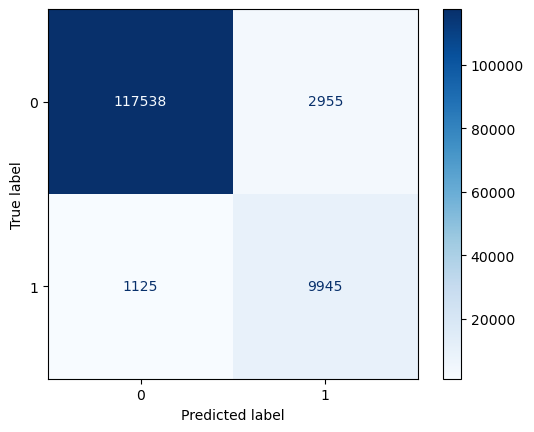

In [35]:
cat_preds = catboost_model.predict(X_test)
cm = confusion_matrix(y_test, cat_preds)
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.savefig(f"catboost_conf_mat.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [19]:
y_true = y_test
predictions = cat_preds
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    120493
           1       0.77      0.90      0.83     11070

    accuracy                           0.97    131563
   macro avg       0.88      0.94      0.91    131563
weighted avg       0.97      0.97      0.97    131563

Precision: 0.7709302325581395
Recall: 0.8983739837398373
F1 Score: 0.8297872340425532


# Limit Shots to ones with reasonable values

In [20]:
df_regression = df
# Dropping lots of rows to be left with values following the physically meaningfull bounds of each feature
df_row_dropped = df_regression[#(df_regression.time_until_disrupt  > 0.02) &
    (df_regression.beta_n >= 0) & (df_regression.beta_n <= 2) #MHD
    & (df_regression.beta_p >= 0) & (df_regression.beta_p <= 1.5) #MHD
    & (df_regression.chisq >= 0.1) & (df_regression.chisq <= 40) #Generic
    & (df_regression.dipprog_dt >= -5e6) & (df_regression.dipprog_dt <= 5e6) #Generic
    & (df_regression.greenwald_fraction >= 0) & (df_regression.greenwald_fraction <= 1.5) #Density
    & (df_regression.kappa >= 0.8) & (df_regression.kappa <= 2) #VDE
    & (df_regression.li >= 0.2) & (df_regression.li <= 4.5) #MHD
    & (df_regression.lower_gap >= 0.025) & (df_regression.lower_gap <= 0.25) #VDE
    & (df_regression.n_e >= 0.2e20) & (df_regression.n_e <= 7e20) #Density
    & (df_regression.n_equal_1_mode >= 0) & (df_regression.n_equal_1_mode <= 0.02) #MHD
    & (df_regression.n_over_ncrit >= -3) & (df_regression.n_over_ncrit <= 3) #VDE
    & (df_regression.p_icrf >= 0) #Density, Radiation
    & (df_regression.p_lh >= 0) #Density, Radiation
    & (df_regression.p_oh >= 0) & (df_regression.p_oh <= 5.0e6) #Density, Radiation
    & (df_regression.p_rad >= 0) #Radiation
    & (df_regression.q0 >= 0) & (df_regression.q0 <= 2) #MHD
    & (df_regression.q95 >= 0) #MHD
    & (df_regression.qstar >= 0) #MHD
    & (df_regression.radiated_fraction >= 0) & (df_regression.radiated_fraction <= 15) #Radiation
    & (df_regression.ssep >= -1) & (df_regression.ssep <= 1) #Generic
    & (df_regression.upper_gap >= 0) #VDE
    & (df_regression.v_loop >= -7) & (df_regression.v_loop <= 7) #Generic, Radiation
    & (df_regression.wmhd >= 0) & (df_regression.wmhd <= 3e5) #Radiation
    & (df_regression.z_error >= -1) & (df_regression.z_error <= 1) #VDE
    & (df_regression.zcur >= -0.5) & (df_regression.zcur <= 0.5) #VDE
    ]
df_row_dropped = df_row_dropped.sample(frac=1.0)

In [21]:
X = df_row_dropped.drop(['Unnamed: 0', 'shot', 'time', 'disruptive', 'time_until_disrupt'], axis=1)

# drop nans and infinities
shot_filter = X.isna() | X.isin([np.inf, -np.inf])
columns_with_nan_or_inf = X.columns[shot_filter.any()].tolist()

X = X.drop(columns_with_nan_or_inf, axis=1)
y = df_row_dropped['disruptive']

# split into train-test-split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True, stratify=y
)

In [22]:
clean_models = [
    XGBClassifier(eval_metric="logloss", random_state=42),
    XGBClassifier(eval_metric="logloss", random_state=42, subsample=0.8, scale_pos_weight=scale_pos_weight),
    XGBClassifier(eval_metric="logloss", random_state=42, max_depth=8),
    XGBClassifier(eval_metric="logloss", random_state=42, max_depth=8, subsample=0.8, scale_pos_weight=scale_pos_weight),
]
names = ["Standard arguments", "Increased disruption weight", "Deeper tree", "Deep tree & more weight"]
results_clean = {}

for model, name in zip(clean_models, names):
    start = time.time()
    model.fit(X_train_clean, y_train_clean)
    train_time = time.time() - start
    preds = model.predict(X_test_clean)
    
    train_acc = accuracy_score(y_train_clean, model.predict(X_train_clean))
    test_acc = accuracy_score(y_test_clean, model.predict(X_test_clean))
    
    results_clean[name] = (model, train_acc, test_acc, train_time, preds)
    
    print(name)
    print(f"  → Train Accuracy: {train_acc:.3f}")
    print(f"  → Test  Accuracy: {test_acc:.3f}")
    print(f"  → Train Time    : {train_time*1000:.2f} ms\n")


Standard arguments
  → Train Accuracy: 0.988
  → Test  Accuracy: 0.980
  → Train Time    : 1792.31 ms

Increased disruption weight
  → Train Accuracy: 0.979
  → Test  Accuracy: 0.969
  → Train Time    : 1330.60 ms

Deeper tree
  → Train Accuracy: 0.996
  → Test  Accuracy: 0.982
  → Train Time    : 1805.80 ms

Deep tree & more weight
  → Train Accuracy: 0.994
  → Test  Accuracy: 0.978
  → Train Time    : 1836.61 ms



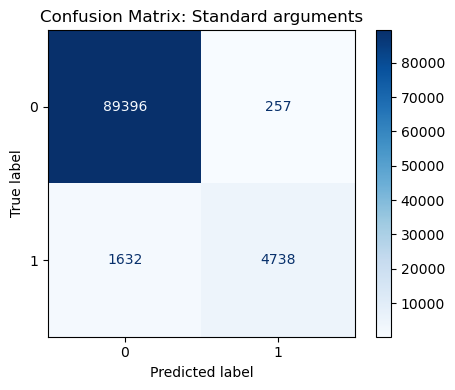

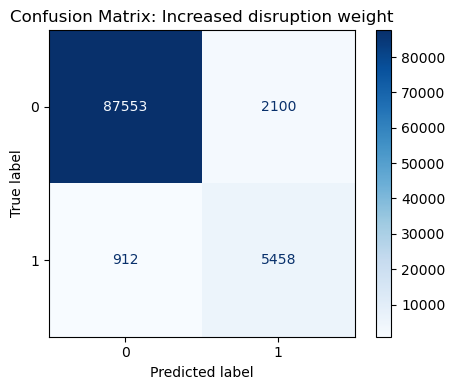

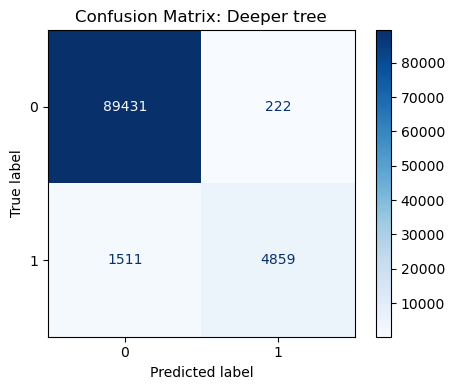

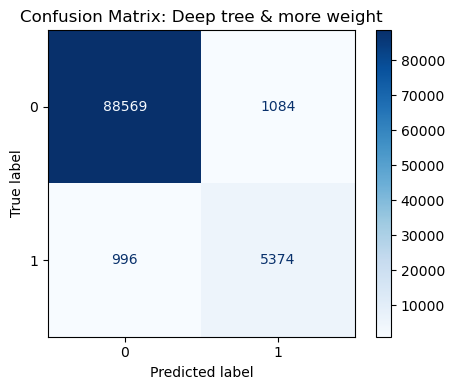

In [27]:
# Custom shortened identifiers matching the order of your names list
file_suffixes = ["std", "weighted", "deep", "deep_weighted"]

for name, suffix in zip(names, file_suffixes):
    # Extract predictions (the 5th entry, index 4, in the tuple)
    model_preds = results_clean[name][4]
    
    # Compute the confusion matrix
    cm = confusion_matrix(y_test_clean, model_preds)
    
    # Set up the plot for this specific model
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
    
    # Dynamic title based on the model's configuration name
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()

    plt.savefig(f"xgboost_conf_mat_clean_{suffix}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [28]:
# CATBOOST 2

dataset_clean = Pool(X_train_clean, label=y_train_clean)
# Add weight
catboost_model_clean = CatBoostClassifier(
    scale_pos_weight=scale_pos_weight,
    verbose=100,  # Keeps the output clean
    random_state=42
)

#train the model
catboost_model_clean.fit(dataset_clean)

Learning rate set to 0.115648
0:	learn: 0.5978648	total: 21.4ms	remaining: 21.3s
100:	learn: 0.2326968	total: 1.86s	remaining: 16.6s
200:	learn: 0.1882372	total: 3.7s	remaining: 14.7s
300:	learn: 0.1593663	total: 5.55s	remaining: 12.9s
400:	learn: 0.1393159	total: 7.37s	remaining: 11s
500:	learn: 0.1243046	total: 9.2s	remaining: 9.16s
600:	learn: 0.1111037	total: 11.1s	remaining: 7.34s
700:	learn: 0.1007835	total: 12.9s	remaining: 5.51s
800:	learn: 0.0916519	total: 14.8s	remaining: 3.67s
900:	learn: 0.0835895	total: 16.6s	remaining: 1.82s
999:	learn: 0.0764826	total: 18.4s	remaining: 0us


CatBoostClassifier(random_state=42, scale_pos_weight=np.float64(10.88435220523475), verbose=100)

Confusion Matrix:
 [[87812  1841]
 [  388  5982]]


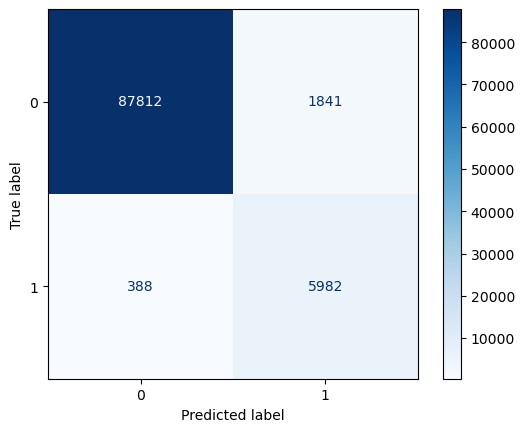

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     89653
           1       0.76      0.94      0.84      6370

    accuracy                           0.98     96023
   macro avg       0.88      0.96      0.92     96023
weighted avg       0.98      0.98      0.98     96023

Precision: 0.7646682858238527
Recall: 0.9390894819466248
F1 Score: 0.8429507503699006


In [34]:
cat_preds = catboost_model.predict(X_test_clean)
cm = confusion_matrix(y_test_clean, cat_preds)
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.savefig(f"catboost_conf_mat_clean.pdf", format="pdf", bbox_inches="tight")
plt.show()
y_true = y_test_clean
predictions = cat_preds
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")